## DeepMaps For GRETA

In [ ]:
library(hdf5r)
library(Matrix)
library(spatstat.core)
library(Signac)
library(Seurat)
source("scRNA_scATAC1.r")

# since we run everything in a sif image, conda crashes and needs to be skipped
Sys.unsetenv("CONDA_PREFIX")
Sys.unsetenv("CONDA_DEFAULT_ENV")
Sys.setenv(CONDA_EXE = "")
Sys.setenv(RETICULATE_PYTHON = "/home/user/miniconda/bin/python")

library(reticulate)

# Patch python_munge_path to return current PATH safely
assignInNamespace(
  "python_munge_path",
  function(python) Sys.getenv("PATH"),  # return valid string, skip conda run
  ns = "reticulate"
)

use_python("/home/user/miniconda/bin/python", required = TRUE)
py_config()

In [ ]:
reticulate::py_run_string("
import torch
info = {
    'torch_version': torch.__version__,
    'cuda_available': torch.cuda.is_available(),
    'cuda_version': torch.version.cuda
}
if torch.cuda.is_available():
    info['gpu_name'] = torch.cuda.get_device_name(0)
")
reticulate::py$info

In [2]:
# create `obj` from `mdata.h5mu`
# `obj`: Seurat object with RNA + ATAC assays ready for DeepMaps

f <- H5File$new("mdata.h5mu", mode = "r")

# RNA raw counts
rna_data    <- f[["mod/rna/layers/counts/data"]][]
rna_indices <- f[["mod/rna/layers/counts/indices"]][]
rna_indptr  <- f[["mod/rna/layers/counts/indptr"]][]
rna_genes   <- f[["mod/rna/var/_index"]][]
rna_cells   <- f[["mod/rna/obs/_index"]][]

rna_counts <- sparseMatrix(
  i = rna_indices + 1,     # convert 0-based to 1-based
  p = rna_indptr,
  x = rna_data,
  dims = c(length(rna_genes), length(rna_cells)),
  dimnames = list(rna_genes, rna_cells)
)

# ATAC raw counts 
atac_data    <- f[["mod/atac/layers/counts/data"]][]
atac_indices <- f[["mod/atac/layers/counts/indices"]][]
atac_indptr  <- f[["mod/atac/layers/counts/indptr"]][]
atac_peaks   <- f[["mod/atac/var/_index"]][]
atac_cells   <- f[["mod/atac/obs/_index"]][]

atac_counts <- sparseMatrix(
  i = atac_indices + 1,
  p = atac_indptr,
  x = atac_data,
  dims = c(length(atac_peaks), length(atac_cells)),
  dimnames = list(atac_peaks, atac_cells)
)

f$close_all()

# Build Seurat object
chrom_assay <- CreateChromatinAssay(
  counts       = atac_counts,
  sep          = c("-", "-"),
  min.cells    = 0,
  min.features = 0
)

obj <- CreateSeuratObject(counts = chrom_assay, assay = "ATAC")
exp_assay <- CreateAssayObject(counts = rna_counts)

obj[["RNA"]] <- exp_assay
DefaultAssay(obj) <- "RNA"
obj[["percent.mt"]] <- PercentageFeatureSet(obj, pattern = "^mt-")

Warning message:
"Keys should be one or more alphanumeric characters followed by an underscore, setting key from atac to atac_"


In [3]:
cat("Cells before filtering:", ncol(obj), "\n")
obj <- filterCell(obj, nmad=3, data_type='scRNA_scATAC')
cat("Cells after filtering:", ncol(obj), "\n")

Cells before filtering: 9631 
Cells after filtering: 8983 


In [4]:
obj

An object of class Seurat 
81920 features across 8983 samples within 2 assays 
Active assay: RNA (16384 features, 0 variable features)
 1 other assay present: ATAC

In [5]:
head(obj@meta.data)

,orig.ident,nCount_ATAC,nFeature_ATAC,nCount_RNA,nFeature_RNA,percent.mt,atac,rna,mito
,<fct>,<dbl>,<int>,<dbl>,<int>,<dbl>,<otlr.flt>,<otlr.flt>,<otlr.flt>
smpl_AAACAGCCAATCCCTT,smpl,5968,2988,3401,1650,0,FALSE,FALSE,FALSE
smpl_AAACAGCCAATGCGCT,smpl,4899,2626,6255,2520,0,FALSE,FALSE,FALSE
smpl_AAACAGCCACCAACCG,smpl,2307,1269,4884,1963,0,FALSE,FALSE,FALSE
smpl_AAACAGCCAGGATAAC,smpl,3197,1724,2509,1198,0,FALSE,FALSE,FALSE
smpl_AAACAGCCAGTTTACG,smpl,6350,3116,3291,1479,0,FALSE,FALSE,FALSE
smpl_AAACATGCAAGGTCCT,smpl,6465,3263,2885,1552,0,FALSE,FALSE,FALSE


In [6]:
#system("/home/user/miniconda/bin/pip install tables")
#r<-system("/home/user/miniconda/bin/python -c 'import tables; print(tables.__version__)'")

In [7]:
# https://github.com/liulab-dfci/MAESTRO/blob/master/R/ATACCalculateGenescore.R
# diag(65000) crashes 

In [4]:
CalGenePeakScore_fixed <-
  function(peak_count_matrix, organism = "GRCh38") {
    pbmc_peak <- peak_count_matrix
    n <- nrow(pbmc_peak)    
    dia <- Diagonal(n)
    rownames(dia) <- rownames(pbmc_peak)
    colnames(dia) <- 1:ncol(dia)
    gene_peak <-
      ATACCalculateGenescore(dia,
                             organism = organism,
                             decaydistance = 10000,
                             model = "Enhanced")
    colnames(gene_peak) <- rownames(peak_count_matrix)
    return (gene_peak)
  }

In [5]:
ATAC_gene_peak <- CalGenePeakScore_fixed(
  peak_count_matrix = obj@assays$ATAC@counts,
  organism = "GRCh38"
)

In [10]:
head(summary(ATAC_gene_peak))

,i,j,x
,<int>,<int>,<dbl>
1,12726,1,9.372462e-01
2,14662,2,9.112381e-01
3,6347,3,4.672284e-01
4,6411,3,3.478478e-02
5,8310,3,9.077786e-05
6,9212,3,3.586162e-05


In [ ]:
obj@assays$ATAC@counts

In [12]:
#  peaks × cells ATAC matrix into a genes × cells regulatory potential matrix — this is the XA' matrix in the paper
# ATAC_gene_peak <- CalGenePeakScore(peak_count_matrix = obj@assays$ATAC@counts, organism = "GRCh38")

In [ ]:
GAS_obj <- calculate_GAS_v1(
  ATAC_gene_peak = ATAC_gene_peak,
  obj = obj,
  method = "wnn"
)

In [14]:
head(summary(GAS_obj))

     Length    Class     Mode
[1,] 132382471 dgCMatrix S4  
[2,]         1 Seurat    S4  

In [7]:
GAS <- GAS_obj[[1]]        
as.matrix(GAS[1:5, 1:5])

# GAS (gene activity score) matrix — genes x cells
# values = gene activity score combining RNA + ATAC weighted by WNN modality weights per cell

,smpl_AAACAGCCAATCCCTT,smpl_AAACAGCCAATGCGCT,smpl_AAACAGCCACCAACCG,smpl_AAACAGCCAGGATAAC,smpl_AAACAGCCAGTTTACG
A1BG,0.01787255,0.0000000,0,0,0.01112003
A1BG-AS1,1.78258456,0.5091956,0,0,0.01504753
A2M,0.00000000,0.7671163,0,0,0.00000000
A2M-AS1,0.00000000,0.0000000,0,0,0.00000000
A2ML1,0.00000000,0.0000000,0,0,0.00000000


In [8]:
obj  <- GAS_obj[[2]]
# updated Seurat obj
# now contains:
# - obj[['ATAC_active']] : gene x cell regulatory potential matrix
# - obj$RNA.weight       : per-cell RNA modality weight
# - obj$ATAC.weight      : per-cell ATAC modality weight
# - obj@reductions$pca
# - obj@reductions$lsi
# - obj@reductions$umap.atac

In [17]:
obj

An object of class Seurat 
96657 features across 8983 samples within 3 assays 
Active assay: ATAC (65536 features, 65536 variable features)
 2 other assays present: RNA, ATAC_active
 3 dimensional reductions calculated: pca, lsi, umap.atac

In [9]:
result_dir <- "/workdir/vangysel/deepmaps/deepmaps_output"
for (subdir in c("gene", "cell", "model", "att")) {
  dir.create(file.path(result_dir, subdir), recursive = TRUE, showWarnings = FALSE)
}

In [10]:
HGT_result <- run_HGT(GAS = as.matrix(GAS),result_dir='/workdir/vangysel/deepmaps/deepmaps_output', data_type='scRNA_scATAC', envPath=NULL, lr=0.2, epoch=30, n_hid=128, n_heads=16)

[1] 30
0.2 30 128 16 0

## Outputs of `run_HGT`
- `GAS` : Integrated matrix X 
- `cell_hgt_matrix` : cell embeddings (8983 cells x 128)  
- `feature_hgt_matrix` : features embeddings (14737 genes x 128)
- `attention` : attention meassage for features and cells (for 16 heads)

In [18]:
names(HGT_result)

[1] "parameters"         "GAS"                "cell_hgt_matrix"   
[4] "feature_hgt_matrix" "attention"          "result_dir"        
[7] "data_type"

In [21]:
HGT_result$parameters

lr,epoch,n_hid,n_heads,cuda
<dbl>,<dbl>,<int>,<int>,<dbl>
0.2,29,128,16,0


In [35]:
head(HGT_result$GAS)
dim(HGT_result$GAS)

,smpl_AAACAGCCAATCCCTT,smpl_AAACAGCCAATGCGCT,smpl_AAACAGCCACCAACCG,smpl_AAACAGCCAGGATAAC,smpl_AAACAGCCAGTTTACG,smpl_AAACATGCAAGGTCCT,smpl_AAACATGCACCGGCTA,smpl_AAACATGCACTTGTTC,smpl_AAACATGCAGCAAGTG,smpl_AAACATGCAGGGAGCT,⋯,smpl_TTTGTGTTCGATAACC,smpl_TTTGTGTTCGGGACCT,smpl_TTTGTGTTCGTCAAGT,smpl_TTTGTGTTCTCCATAT,smpl_TTTGTTGGTCAGGAAG,smpl_TTTGTTGGTGACATGC,smpl_TTTGTTGGTGTTAAAC,smpl_TTTGTTGGTTAGGATT,smpl_TTTGTTGGTTGGTTAG,smpl_TTTGTTGGTTTGCAGA
A1BG,0.01787255,0.0000000,0,0,0.01112003,0.0000000000,0.00712234,0.542904401,0,0,⋯,0.4207117,0.0000000000,0.0151037786,0.01869775,0,0.0000000000,0.0175782012,0.009394183,0,0
A1BG-AS1,1.78258456,0.5091956,0,0,0.01504753,0.5034784102,0.01628401,0.000000000,0,0,⋯,0.0000000,0.0000000000,0.0151651794,0.53293447,0,0.5193040553,0.0142857385,0.013084688,0,0
A2M,0.00000000,0.7671163,0,0,0.00000000,0.0000000000,0.00000000,0.000000000,0,0,⋯,0.0000000,0.0009246854,0.4407496784,0.48091616,0,0.0000000000,0.0007512494,0.000000000,0,0
A2M-AS1,0.00000000,0.0000000,0,0,0.00000000,0.0003437482,0.00000000,0.000000000,0,0,⋯,0.0000000,0.0318509790,0.0127685399,0.01252974,0,0.0002295665,0.0287186236,0.000000000,0,0
A2ML1,0.00000000,0.0000000,0,0,0.00000000,0.0001674454,0.00000000,0.000000000,0,0,⋯,0.0000000,0.0000000000,0.0000000000,0.00000000,0,0.0002565451,0.0000000000,0.000000000,0,0
A3GALT2,0.00000000,0.0000000,0,0,0.00000000,0.0000000000,0.00000000,0.001258646,0,0,⋯,0.0000000,0.0000000000,0.0002195119,0.21372545,0,0.0000000000,0.0000000000,0.000000000,0,0


[1] 14737  8983

In [29]:
head(HGT_result$cell_hgt_matrix)
dim(HGT_result$cell_hgt_matrix)

smpl_AAACAGCCAATCCCTT,0.08074611,-0.011026968,-0.004699042,0.06918532,0.02036011,-0.02794332,0.08514194,0.10537454,0.1022862,0.009424124,⋯,-0.020598818,-0.034180187,-0.004290235,-0.04617434,0.09607111,-0.006099263,-0.06677476,-0.04197435,0.00447505,-0.07566840
smpl_AAACAGCCAATGCGCT,0.07539201,-0.014590229,-0.028649440,0.07920791,0.04313448,-0.03937767,0.06265585,0.08879943,0.1191147,0.026410157,⋯,-0.023248121,-0.022776745,0.014410510,-0.05281148,0.11219363,-0.003531686,-0.05543921,-0.06197379,0.01568852,-0.06098189
smpl_AAACAGCCACCAACCG,0.04526725,-0.021766674,-0.029645443,0.07950486,0.01606878,-0.04374158,0.05307747,0.08934326,0.1409630,0.041306105,⋯,-0.009528588,-0.042691190,0.017590472,-0.06290060,0.10243493,0.007004238,-0.04913284,-0.02953312,0.02163996,-0.04861813
smpl_AAACAGCCAGGATAAC,0.05458046,-0.029277094,-0.016734732,0.08198324,0.01646067,-0.02307855,0.07012791,0.09070532,0.1264957,0.024984434,⋯,-0.005309948,-0.019974152,0.004804914,-0.04178907,0.11763451,0.015020259,-0.04443424,-0.05491465,0.02122514,-0.06563175
smpl_AAACAGCCAGTTTACG,0.06814684,-0.008903068,-0.019255517,0.06536134,0.01288012,-0.02560087,0.04917999,0.09984478,0.1094354,0.033985537,⋯,-0.008187120,-0.016328739,0.001425607,-0.04277509,0.10472422,-0.001505458,-0.03732521,-0.05231715,0.02977868,-0.05649722
smpl_AAACATGCAAGGTCCT,0.07592718,-0.008965544,-0.014422175,0.09742667,0.01929674,-0.03488198,0.06642674,0.09190679,0.1061678,0.010126771,⋯,-0.010060232,-0.009666156,-0.001664820,-0.03933775,0.11108793,-0.010604954,-0.05129552,-0.05514161,0.01046246,-0.04004113


[1] 8983  128

In [36]:
head(HGT_result$feature_hgt_matrix)
dim(HGT_result$feature_hgt_matrix)

A1BG,0.11223552,-0.048617668,-0.024686536,0.05422227,-1.923257e-02,-0.005083472,-0.044733319,-0.031619839,-0.01550963,-0.05512437,⋯,-0.04163537,0.026250597,0.007233155,0.015313357,0.07120634,-0.06354897,0.054604907,-1.512543e-02,0.016126087,-3.804306e-02
A1BG-AS1,0.12130100,-0.038564458,-0.030236783,0.04901183,-2.922988e-02,-0.002388234,-0.066176392,-0.038055226,-0.01071837,-0.05156539,⋯,-0.03698623,0.035132483,-0.019100057,0.016094983,0.06129780,-0.06223380,0.042401154,-3.160154e-02,0.010780318,-3.137600e-02
A2M,0.08831467,0.014078927,-0.068035036,-0.03192452,3.881650e-03,-0.059805259,0.008868791,-0.033393290,0.09928681,-0.04852377,⋯,-0.08817143,0.059729278,0.019392513,0.097419254,0.08680866,-0.07552464,0.009966817,-1.005406e-02,0.050033286,-5.246961e-05
A2M-AS1,0.10124101,0.016958466,-0.034279276,-0.00424471,6.729661e-05,-0.042151127,0.013006992,-0.022042450,0.10227677,-0.03839399,⋯,-0.06844448,0.043202728,0.030450407,0.085527398,0.08895093,-0.10783157,0.021024074,-6.254993e-03,0.024557222,8.736838e-04
A2ML1,0.06000346,0.023024224,-0.005011906,0.04183663,6.933105e-02,0.006143893,-0.007280562,0.015536663,0.08263413,-0.04588505,⋯,0.02146137,0.004981656,0.062732540,-0.027025465,0.03429015,-0.09129412,0.005948219,1.837684e-02,-0.015923956,7.428653e-03
A3GALT2,0.07339876,0.009484673,-0.026208427,0.04743677,5.727638e-02,0.003169551,-0.030515211,-0.001665168,0.05407105,-0.04361418,⋯,0.01792155,0.010802273,0.030856403,-0.004437052,0.04687323,-0.09787744,0.019298965,-9.007339e-05,0.002181338,-7.071294e-03


[1] 14737   128

In [34]:
head(HGT_result$attention)
dim(HGT_result$attention)

,gene,cell,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0,0,3.049609e-09,-3.058537e-08,-3.893858e-08,-2.186375e-08,-7.933616e-09,-3.870380e-09,-8.276014e-09,-2.137534e-08,5.969626e-08,-2.452031e-08,-2.774141e-08,2.846367e-08,4.481164e-08,5.269031e-09,-1.574053e-08,-2.581788e-08
2,0,4,4.903595e-09,-3.404682e-08,-4.003791e-08,-2.479523e-08,-1.374804e-08,-7.193825e-09,-2.115932e-08,-4.399609e-08,7.057685e-08,-2.287987e-08,-3.572897e-08,4.070090e-08,3.598178e-08,1.674861e-09,-1.053294e-08,-2.365849e-08
3,0,6,-6.071281e-09,-3.383257e-08,-1.739173e-08,-2.969815e-08,-1.011854e-08,-2.047774e-08,8.158915e-09,-2.784241e-08,7.384337e-08,-2.051266e-08,-3.519125e-08,3.971120e-08,4.402485e-08,2.277910e-08,-2.212202e-08,-2.823135e-08
4,0,7,-1.315611e-09,-3.704413e-08,-2.857113e-08,-2.767649e-08,-9.995133e-09,-1.375292e-08,-6.424980e-09,-3.378349e-08,6.079001e-08,-1.948223e-08,-2.927095e-08,3.341639e-08,4.736800e-08,1.861901e-08,-1.893643e-08,-2.590477e-08
5,0,11,-6.461819e-09,-1.756210e-08,-1.876676e-10,-3.249204e-08,-1.393821e-08,-2.389841e-08,1.124722e-08,-1.722195e-08,7.863621e-08,-1.026616e-08,-3.993450e-08,3.609198e-08,4.805531e-08,6.086531e-09,-1.114360e-08,-3.547917e-08
6,0,12,-2.993571e-10,-4.367829e-08,-2.422869e-08,-3.554977e-08,-1.405849e-08,-1.695245e-08,-1.162019e-08,-4.010890e-08,8.106608e-08,-2.542885e-08,-3.583047e-08,4.229782e-08,3.144104e-08,1.361811e-08,-1.584459e-08,-2.838344e-08


[1] 45356398       18

In [27]:
HGT_result$result_dir

[1] "/workdir/vangysel/deepmaps/deepmaps_output"

In [28]:
HGT_result$data_type

[1] "scRNA_scATAC"

### About the embeddings
| Step                | Embedding dim | Notes                                          |
|--------------------|---------------|------------------------------------------------|
| AE (autoencoder)    | 256           | Initial feature reduction of gene/cell matrix |
| HGT (GNN)           | 128           | Graph-based learning, final node embeddings used downstream |

## Cluster the cells

In [ ]:
# Ensure the order of cells matches the Seurat obj
cell_hgt_matrix <- HGT_result[['cell_hgt_matrix']]        # cell embeddings : n_cells x 128
rownames(cell_hgt_matrix) <- colnames(GAS)                # GAS : n_genes x n_cells 
obj <- obj[, colnames(GAS)]
cell_hgt_matrix <- cell_hgt_matrix[colnames(GAS),]

# Add HGT as a dimensional reduction
HGT_embedding <-
  CreateDimReducObject(embeddings = cell_hgt_matrix,
                       key = "HGT_",
                       assay = "RNA")

obj@reductions[['HGT']] <- HGT_embedding

# Preprocess RNA
obj <-
  FindVariableFeatures(obj, selection.method = "vst", nfeatures = 2000)

obj <- ScaleData(obj, features = VariableFeatures(obj))

# Compute UMAP from HGT cell embedding 
obj <-
  RunUMAP(
    obj,
    reduction = 'HGT',
    dims = 1:ncol(cell_hgt_matrix),
    reduction.name = "umap.rna",
    reduction.key = "rnaUMAP_"
  )

# Build neighbor graph
obj <-
  FindNeighbors(obj,
                reduction = "HGT",
                dims = 1:ncol(cell_hgt_matrix))

# Cluster cells
obj <- FindClusters(obj, graph.name = "RNA_snn", resolution = 1)

DefaultAssay(obj) <- "RNA"

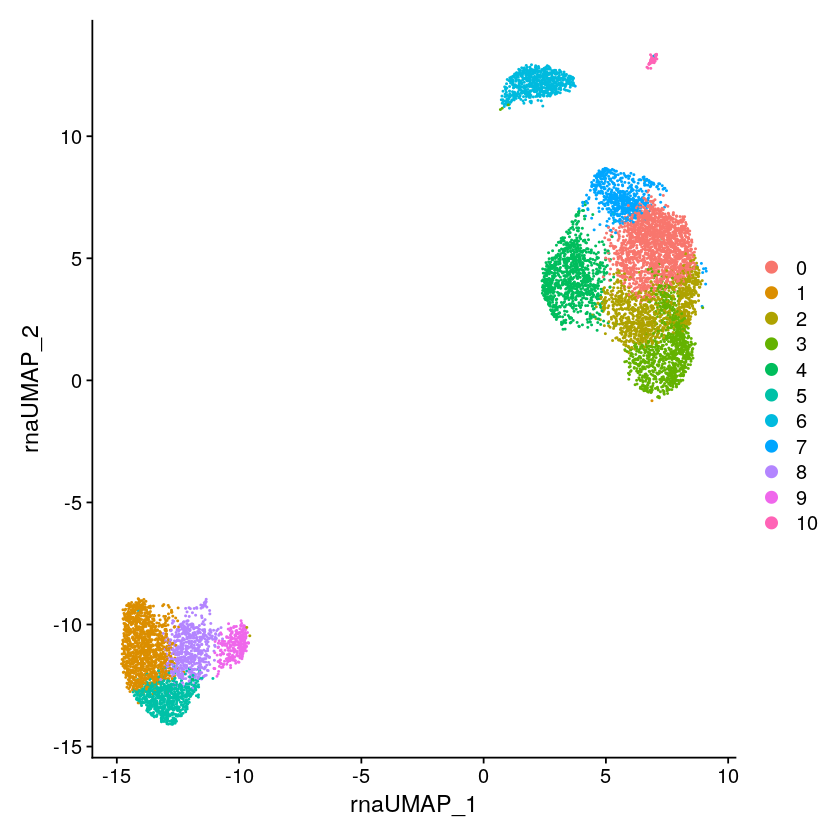

In [45]:
DimPlot(obj, reduction = 'umap.rna')

In [61]:
names(obj)

[1] "ATAC"        "RNA"         "ATAC_active" "GAS"         "wknn"       
 [6] "wsnn"        "RNA_nn"      "RNA_snn"     "pca"         "lsi"        
[11] "umap.atac"   "HGT"         "umap.rna"

## FeaturePlot
Plots the expression of each gene on the UMAP/tSNE embedding.
Each cell is a dot; color intensity shows expression level.

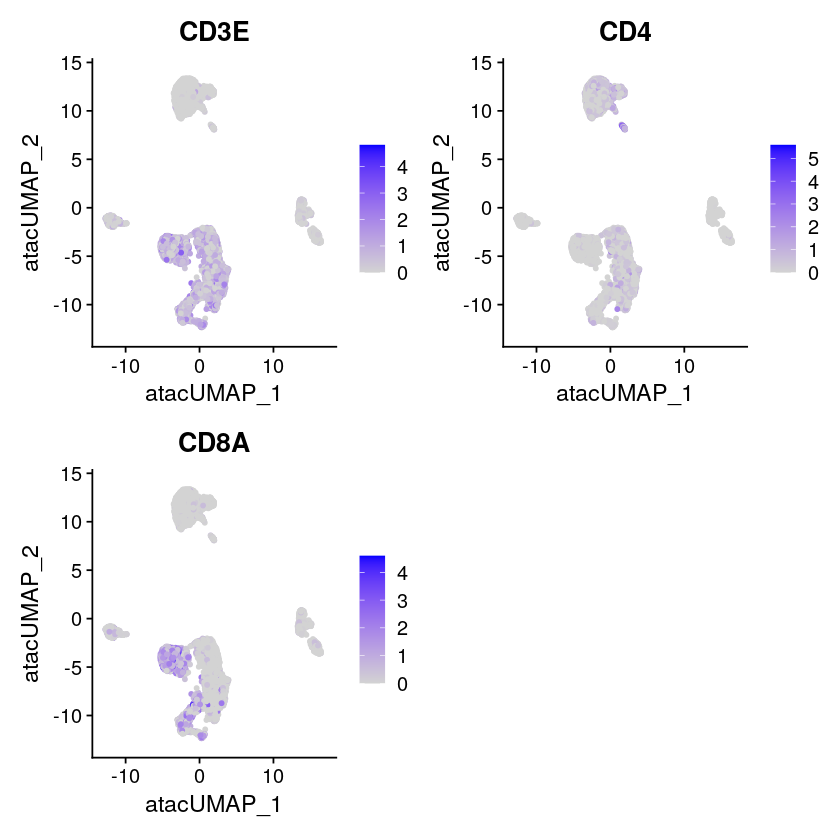

In [65]:
GAS_assay <-
      CreateAssayObject(counts = GAS,
                        min.cells = 0)

obj[['GAS']] <- GAS_assay
genelist <- c('CD3E', 'CD4', 'CD8A')
DefaultAssay(obj) <- "GAS"
FeaturePlot(
  obj,
  features = genelist,
  
  #ncol = 3,
  keep.scale = NULL,
  pt.size = 1
)

## The Violin plot of marker genes

Warning message:
"Removed 1 rows containing non-finite values (stat_ydensity)."


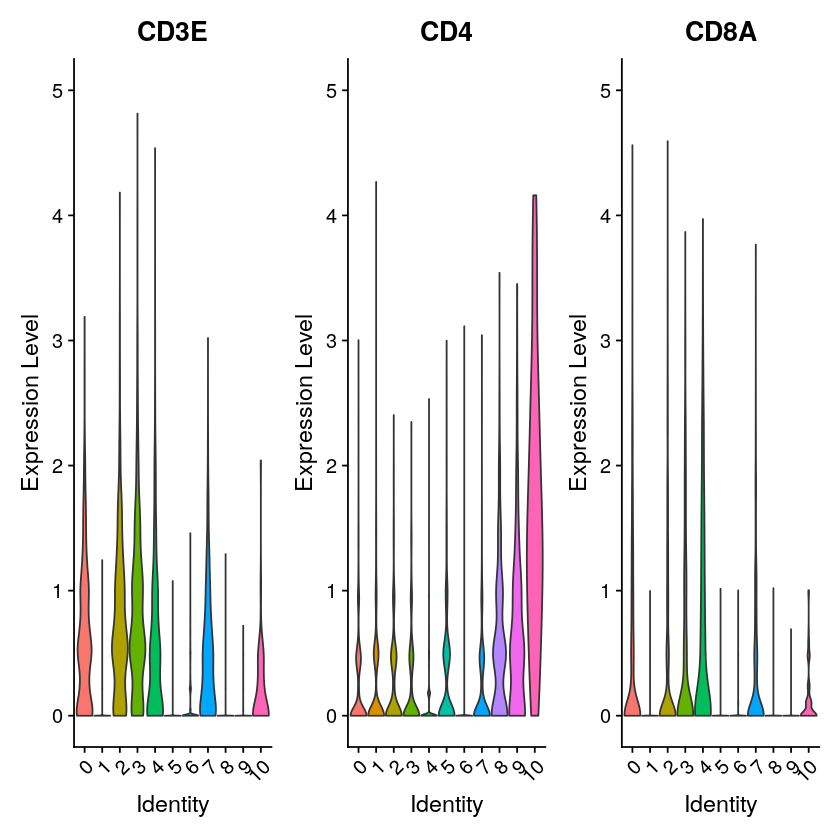

In [69]:
genelist <- c('CD3E', 'CD4', 'CD8A')
VlnPlot(
  obj,
  features = genelist,
  assay = 'GAS',
  y.max = 5,
  #ncol = 3,
  pt.size = 0
)

## Cell type annotation and show UMAP

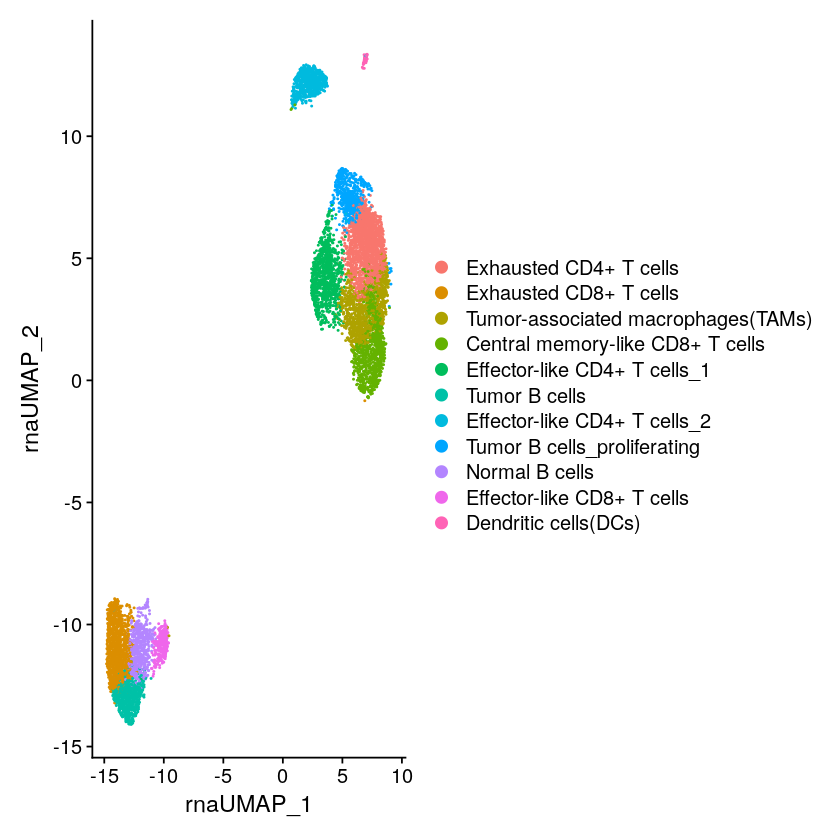

In [71]:
# rename 
new.cluster.ids <-
  c(
    'Exhausted CD4+ T cells',
    'Exhausted CD8+ T cells',
    'Tumor-associated macrophages(TAMs)',
    'Central memory-like CD8+ T cells',
    'Effector-like CD4+ T cells_1',
    'Tumor B cells',
    'Effector-like CD4+ T cells_2',
    'Tumor B cells_proliferating',
    'Normal B cells',
    'Effector-like CD8+ T cells',
    'Dendritic cells(DCs)'

  )
names(new.cluster.ids) <- levels(obj)
obj <- RenameIdents(obj, new.cluster.ids)

In [ ]:
DimPlot(obj, reduction = 'umap.rna')

## Calculate cell cluster active gene modules and run LISA for TF infer.
`get_gene_module` calculates cell-type-specific active gene modules. 

These are sets of genes that are strongly “active” in a specific cell type, derived from the gene activity score (GAS), HGT embeddings, and attention values from the HGT model.

In [76]:
dir.create("db", showWarnings = FALSE)
system("wget http://cistrome.org/~alynch/data/lisa_data/hg38_1000_2.0.h5 -O db/hg38_1000_2.0.h5")

In [77]:
system("wget https://bmblx.bmi.osumc.edu/downloadFiles/deepmaps/jaspar_hg38_500.qsave -O db/jaspar_hg38_500.qsave")

In [78]:
# CT active gene modules calculation
# input:
#  obj: a seurat object
#  GAS: a gene active matrix with gene * cell which return from calculate_GAS function
#  cell_hgt_matrix: cell-embedding matrix which otains from HGT function
#  att: attention matrix with gene-cell * head which obtain from HGT function
#output:
#  co (variable 1): a biological gene module. a list with name CT-i and active gene list in CT-i
co <- get_gene_module(obj = obj, GAS = GAS, att = HGT_result[['attention']],method = 'SFP' )

In [87]:
head(co)
summary(co)

$ct_0
 [1] "ANKRD44" "DENND1A" "DOCK8"   "EPSTI1"  "FOXN3"   "FYB1"    "JMJD1C" 
 [8] "MALAT1"  "MBNL1"   "NEAT1"   "PARP14"  "PELI1"   "RNF213"  "RPL13A" 
[15] "SIK3"    "SIPA1L1" "SMCHD1"  "STK17B"  "VMP1"   

$ct_1
 [1] "AKAP13"  "ANKRD44" "BACH2"   "DDX60L"  "DENND1A" "DOCK10"  "DOCK8"  
 [8] "DPYD"    "EEF1A1"  "EPSTI1"  "FOXN3"   "FYB1"    "GBP2"    "JMJD1C" 
[15] "LTB"     "MALAT1"  "MBNL1"   "NEAT1"   "PARP14"  "PELI1"   "RNF213" 
[22] "RPL13A"  "RPL3"    "RPS2"    "SIK3"    "SIPA1L1" "SMCHD1"  "STAT1"  
[29] "STK17B"  "USP15"   "VMP1"   

$ct_2
 [1] "AKAP13"   "ANKRD44"  "COL6A5"   "DENND1A"  "DOCK8"    "EPSTI1"  
 [7] "FOXN3"    "FYB1"     "JMJD1C"   "MALAT1"   "MBNL1"    "NEAT1"   
[13] "PARP14"   "PELI1"    "RNF213"   "RPL13A"   "RUNX1"    "SIK3"    
[19] "SIPA1L1"  "SMCHD1"   "STK17B"   "TMEM131L" "TXNDC8"   "VMP1"    

$ct_3
 [1] "ANKRD44"     "CD1B"        "CD1E"        "DENND1A"     "DOCK8"      
 [6] "FYB1"        "HCRTR2"      "JMJD1C"      "L3MBTL4-AS1" "LINC00616"  
[11] "MALAT1"      "MBNL1"       "MIR548A1HG"  "MMP2"        "MMP2-AS1"   
[16] "NEAT1"       "PELI1"       "RXYLT1-AS1"  "SIPA1L1"     "SMCHD1"     
[21] "STK17B"      "TDRD15"      "VMP1"        "ZNF503"      "ZNF503-AS2" 

$ct_4
 [1] "ADAMTSL4-AS1" "AKAP13"       "ANKRD44"      "DENND1A"      "DOCK8"       
 [6] "DPYD"         "EPSTI1"       "FOXN3"        "FYB1"         "JMJD1C"      
[11] "LINC01050"    "MALAT1"       "MBNL1"        "NEAT1"        "PARP14"      
[16] "PELI1"        "RNF213"       "RPL13A"       "RUNX1"        "SIK3"        
[21] "SIPA1L1"      "SMCHD1"       "STAT1"        "STK17B"       "TMEM131L"    
[26] "USP15"        "VMP1"        

$ct_5
 [1] "ANKRD44" "BACH2"   "DENND1A" "DOCK10"  "DOCK8"   "DPYD"    "EPSTI1" 
 [8] "FOXN3"   "FYB1"    "JMJD1C"  "MALAT1"  "MBNL1"   "NAP1L3"  "NEAT1"  
[15] "PARP14"  "PELI1"   "RNF213"  "RPL13A"  "SIK3"    "SIPA1L1" "SMCHD1" 
[22] "STAT1"   "STK17B"  "USP15"   "VMP1"

      Length Class  Mode     
ct_0  19     -none- character
ct_1  31     -none- character
ct_2  24     -none- character
ct_3  25     -none- character
ct_4  27     -none- character
ct_5  25     -none- character
ct_6  21     -none- character
ct_7  17     -none- character
ct_8  32     -none- character
ct_9  33     -none- character
ct_10 15     -none- character

In [88]:
# gene module save
#input:
#  co: the active gene module from get_gene_module function
#  lisa_path: the path of active gene module to save
#result
#  write gene module to the lisa_path
lisa_path <- "/workdir/vangysel/deepmaps/git/db/"
dir.create(lisa_path, showWarnings = F)
write_GM(co = co, lisa_path = lisa_path)

In [104]:
cmd <- "/home/user/miniconda/bin/python"
args <- c("run_lisa.py",
          "--path", lisa_path,
          "--species", "hg38")

# capture both stdout and stderr
output <- system2(command = cmd, args = args, stdout = TRUE, stderr = TRUE)

# print all messages
cat(output, sep = "\n")

Warning message in system2(command = cmd, args = args, stdout = TRUE, stderr = TRUE):
"running command ''/home/user/miniconda/bin/python' run_lisa.py --path /workdir/vangysel/deepmaps/git/db/ --species hg38 2>&1' had status 1"


Grabbing hg38 data (~15 minutes):
Traceback (most recent call last):
  File "run_lisa.py", line 25, in <module>
    lisa_test = FromGenes('hg38', rp_map='enhanced_10K',
  File "/home/user/miniconda/lib/python3.8/site-packages/lisa/lisa_public_data/genes_test.py", line 78, in __init__
    super().__init__(species, _config, self.window_size, isd_method= isd_method, verbose=verbose, log=log)
  File "/home/user/miniconda/lib/python3.8/site-packages/lisa/core/lisa_core.py", line 74, in __init__
    self.data_interface = DataInterface(species, window_size=window_size, make_new=False,
  File "/home/user/miniconda/lib/python3.8/site-packages/lisa/core/data_interface.py", line 99, in __init__
    self.download_data()
  File "/home/user/miniconda/lib/python3.8/site-packages/lisa/core/data_interface.py", line 477, in download_data
    self.fetch_from_cistrome(self.species, self.window_size)
  File "/home/user/miniconda/lib/python3.8/site-packages/lisa/core/data_interface.py", line 67, in fetch_fr

In [102]:
#run lisa.py in the LISA environment
system(
  paste0(
    "/home/user/miniconda/bin/python run_lisa.py --path ",
    lisa_path,
    " --species ",
    "hg38"
  )
)

## Filter gene with no accessible peak in promoter

In [90]:
# Filter gene with no accessible peak in promoter 
# input:
#  lymph_obj: a seurat object which return from filterCell function
#  gene_peak: a matrix with gene * peak from scATAC-seq which return from filterCell function 
#  GAS: the GAS matrix with gene * cell which return calculate_GAS function
#  species: hg38 / mm10
#output:
# a matrix with gene * peak. The gene with no accessible peak will be removed
gene_peak_pro <- AccPromoter(obj = lymph_obj, gene_peak = ATAC_gene_peak, GAS = GAS, species = 'hg38')

 chr [1:9433] "SAMD11" "ISG15" "AGRN" "AGRN" "C1orf159" "LINC01342" ...


In [ ]:
gene_peak_pro # 9433 x 65536

## Infer candicate cell type active regulons

In [ ]:
## infer ct active regulons
# input:
# GAS: the GAS matrix with gene * cell which return calculate_GAS function
# co: a list of bio network which reture from gene_ function 
# gene_peak_pro: the matrix with gene * peak which return AccPromoter function
# species: human / mouse (human = "hg38", mouse = "mm10" )
# jaspar_path: if speices == human, the TF binding RData absolute path of hg38 should be provided,if speices == mouse, the TF binding RData absolute path of mm10 should be provided
# lisa_path: the co saved path
#output:
# BA_score a TF binding affinity matrix with TF * peak, the elements in the matrix is the binding power of TF to peak 
# ct_regulon: candidate cell type active regulon
# TFinGAS: TRUE / FALSE, if number of the intersection of candidate TF from LISA and gene in GAS > 50 TFinGAS will be true, else it will be false
pre_regulon_res <- Calregulon(GAS = GAS, co = co, gene_peak_pro = gene_peak_pro, species = "hg38", jaspar_path = "/workdir/vangysel/deepmaps/git/db/", lisa_path = lisa_path)
BA_score <- pre_regulon_res[[1]]
ct_regulon_v1 <- pre_regulon_res[[2]]
TFinGAS<- pre_regulon_res[[3]]

## Explained workflow 

From the integrated matrix `X` (aka GAS matrix) which contains gene activity scores (genes x cells), we can call `arg.py` which performs the following steps: 

1. Feature extraction (Autoencoder)
2. Build heterogeneous graph
3. Train HGT model
4. Extract embeddings + attention scores
        
Returns: cell embeddings, gene embeddings, attention scores

### 1. Feature extraction via Autoencoder

Use two autoencoders to learn initial cell and genes embeddings (Feature extraction step). <br>
The high-dimensional GAS gets compressed into 256-dim vectors for both genes and cells.

```python
# Gene autoencoder: genes × cells → genes × 256
AE(dim=n_cells) → encoded   # gene embeddings

# Cell autoencoder: cells × genes → cells × 256  
AE(dim=n_genes) → encoded2  # cell embeddings
```

The node features are then stored in `x`
```ptyhon
x = {
  'gene': torch.tensor(encoded, dtype=torch.float),   # 14737 × 256
  'cell': torch.tensor(encoded2, dtype=torch.float),  # 8971  × 256
}
```

### 2. Build heterogeneous graph 

GAS matrix is `gene_cell` here

- Nodes: 

    ```python
    g = np.nonzero(gene_cell)[0]                       # row indices where GAS > 0 → gene IDs
    c = np.nonzero(gene_cell)[1] + gene_cell.shape[0]  # col indices → cell IDs (shifted by n_genes)

    ```
    <br>
    
- Edges: `gene_i` → `cell_j` if `GAS[i,j] > 0`

```python
edge1 = list(g)    # row 0 = source gene IDs
edge2 = list(c)    # row 1 = target cell IDs
edge_index = torch.tensor([edge1, edge2], dtype=torch.float)    # shape: 2 × n_edges
```


Each cell and gene get a global id (cell nodes are shifted by n_genes to get global cell ID)
`x` will is a dict with both cells and genes
```python
Global node space:
[0    ...    14736 | 14737  ...  23707]
[  gene nodes      |   cell nodes     ]

Edge example (GAS[3,5] > 0):
gene_3 ──────────────────► cell_14742
  ↑                              ↑
x['gene'][3]              x['cell'][5]
(local gene index)        (local cell index)
(global ID = 3)           (global ID = 5+14737)
```

**About the custom Graph() object** 
```python 
graph = Graph()         # DeepMAPS custom graph class from pyHGT/data.py
edg = graph.edge_list   # nested defaultdict: edg[target][source][relation]
```

All edges are bidirectional :
- gene &rarr; cell `edg['cell']['gene']['g_c']`
- cell &rarr; gene `edg['gene']['cell']['rev_g_c']`
